
## Tugas Ho2 - Pengolahan Sinyal Biomedis

Nama            : **Arof Andestama**  
NIM             : **121140182**  
Tanggal Lahir   : **1 April 2003**  


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy import signal
from scipy.fft import fft, fftfreq
import soundfile as sf
import IPython.display as ipd
from scipy.io.wavfile import write

## Bagian 1: Simulasi Sinyal PPG dan Downsampling

- **Durasi:** 182 detik  
- **Sampling Rate:** 150 Hz  
- **Noise Level:** 0.82  
- **Heart Rate:** 80 BPM  
- **Random State:** 030401


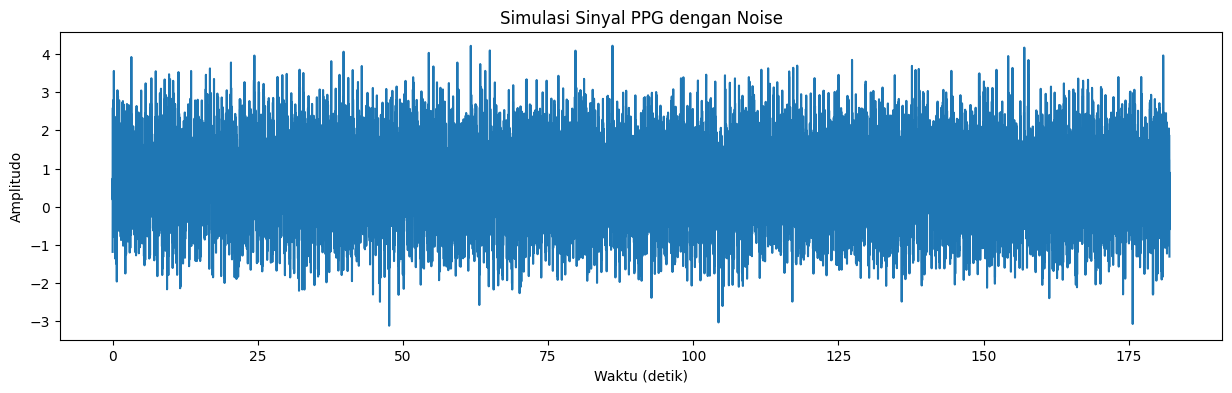

In [53]:
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt

# Parameter
duration = 182  # dari 3 digit terakhir NIM 121140182
sampling_rate = 150
heart_rate = 80
random_state = 30401
noise_level = 0.82  # dari 2 digit terakhir NIM

# Simulasi sinyal PPG (tanpa noise)
ppg = nk.ppg_simulate(duration=duration, sampling_rate=sampling_rate,
                      heart_rate=heart_rate, random_state=random_state)

# Tambahkan noise secara manual
np.random.seed(random_state)
ppg_noisy = ppg + np.random.normal(0, noise_level, len(ppg))

# Plot
time = np.linspace(0, duration, len(ppg_noisy))
plt.figure(figsize=(15, 4))
plt.plot(time, ppg_noisy)
plt.title("Simulasi Sinyal PPG dengan Noise")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.show()


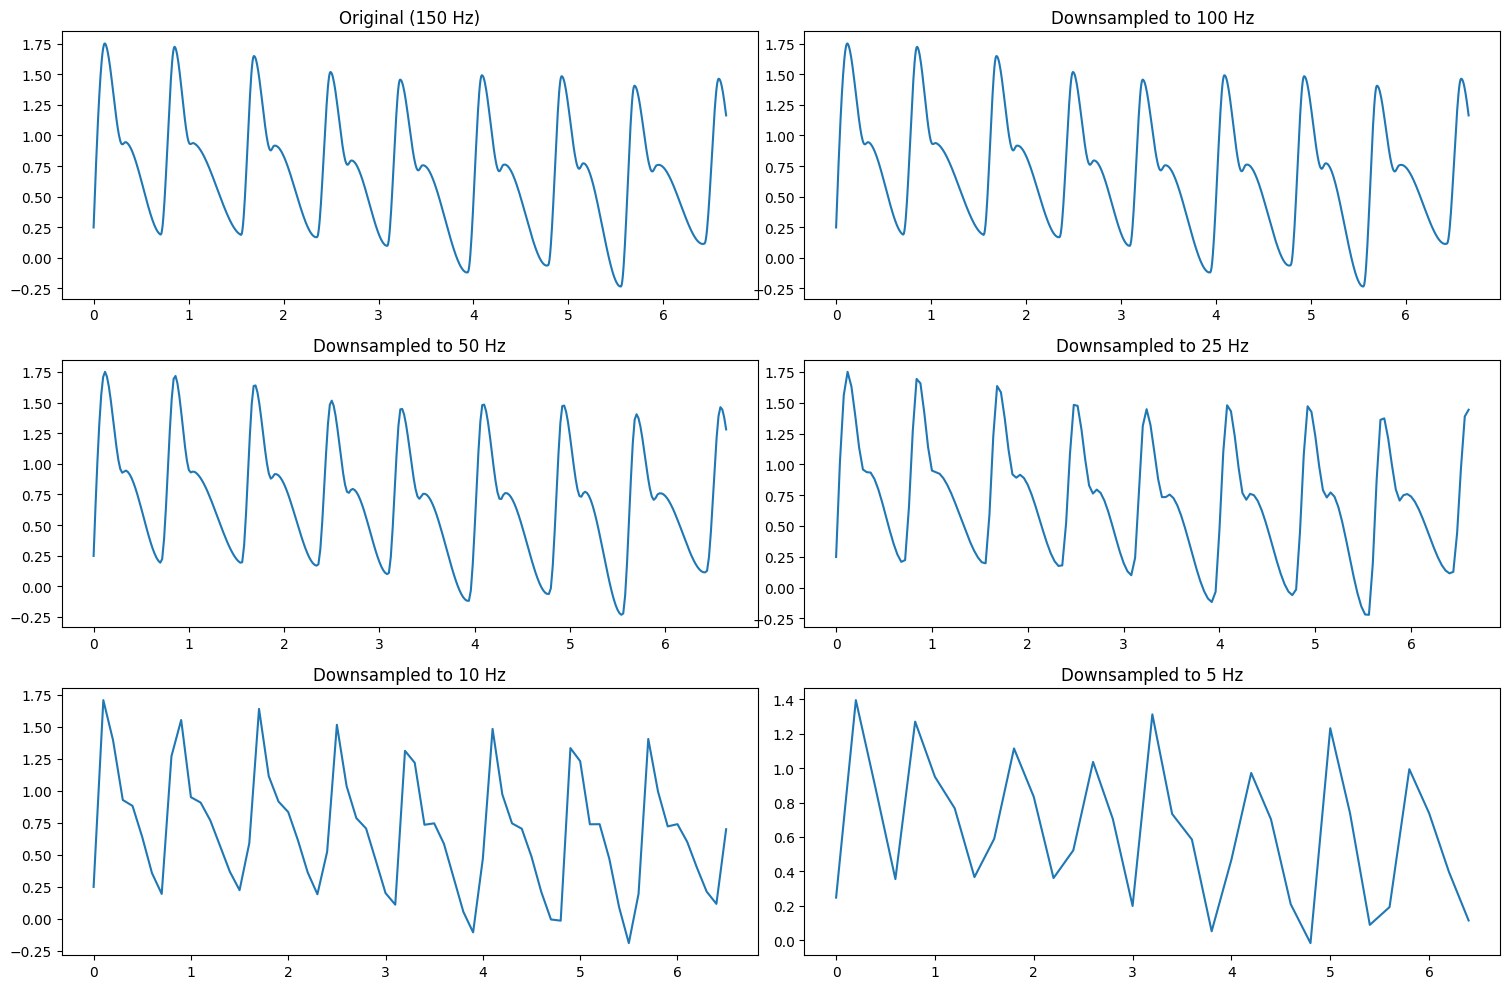

In [54]:

from scipy.signal import resample

fs_list = [100, 50, 25, 10, 5]
plt.figure(figsize=(15, 10))
plt.subplot(3, 2, 1)
plt.plot(time[:1000], ppg[:1000])
plt.title("Original (150 Hz)")

for i, fs_new in enumerate(fs_list):
    factor = int(sampling_rate / fs_new)
    ppg_ds = ppg[::factor]
    time_ds = time[::factor]
    plt.subplot(3, 2, i+2)
    plt.plot(time_ds[:1000//factor], ppg_ds[:1000//factor])
    plt.title(f"Downsampled to {fs_new} Hz")
plt.tight_layout()
plt.show()


## Penjelasan Aliasing

Aliasing terjadi ketika frekuensi sampling (fs) terlalu rendah untuk menangkap detail sinyal frekuensi tinggi, sehingga sinyal tersebut tampak terdistorsi atau "menyamar" sebagai sinyal lain. Ini terjadi jika fs < 2x frekuensi tertinggi sinyal (melanggar Teorema Nyquist).

Semakin rendah fs, informasi penting hilang dan sinyal tampak kasar atau berubah bentuk.


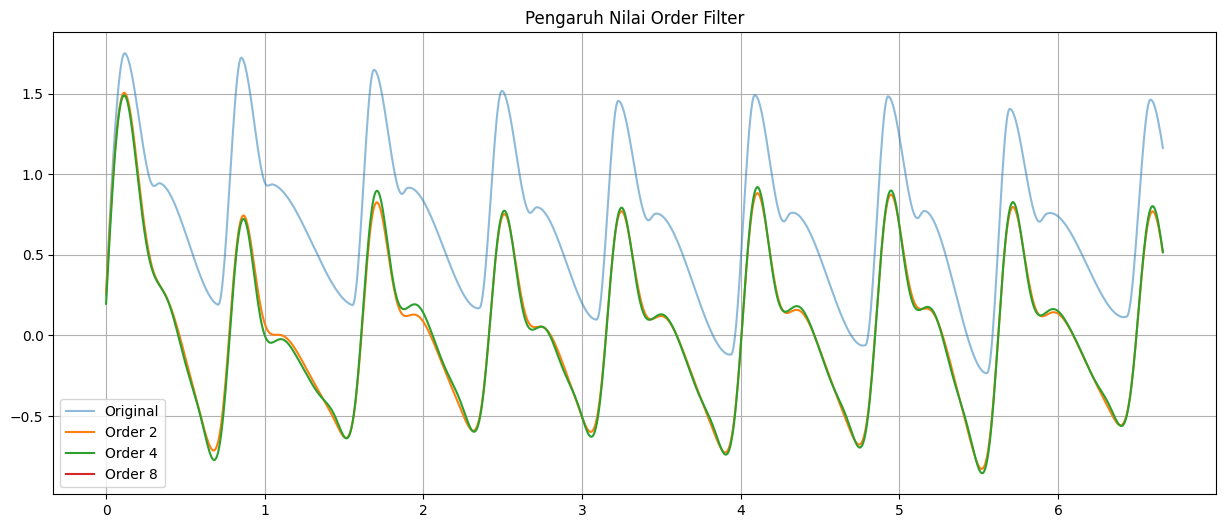

In [55]:

b1, a1 = signal.butter(2, [0.5, 5], btype='band', fs=sampling_rate)
b2, a2 = signal.butter(4, [0.5, 5], btype='band', fs=sampling_rate)
b3, a3 = signal.butter(8, [0.5, 5], btype='band', fs=sampling_rate)

ppg_f2 = signal.filtfilt(b1, a1, ppg)
ppg_f4 = signal.filtfilt(b2, a2, ppg)
ppg_f8 = signal.filtfilt(b3, a3, ppg)

plt.figure(figsize=(15, 6))
plt.plot(time[:1000], ppg[:1000], label='Original', alpha=0.5)
plt.plot(time[:1000], ppg_f2[:1000], label='Order 2')
plt.plot(time[:1000], ppg_f4[:1000], label='Order 4')
plt.plot(time[:1000], ppg_f8[:1000], label='Order 8')
plt.legend()
plt.title("Pengaruh Nilai Order Filter")
plt.grid()
plt.show()


## Penjelasan Parameter Order

'Order' menunjukkan tingkat kompleksitas filter dan kemiringan pemotongan (roll-off). 
- Semakin tinggi order, semakin tajam filter membedakan antara frekuensi pass dan stop. 
- Namun, nilai terlalu tinggi bisa menyebabkan **overfitting** atau delay.



## Bagian 2: Filter Bandpass untuk Sinyal Respirasi

- **Durasi:** 182 detik  
- **Sampling Rate:** 100 Hz  
- **Noise Level:** 0.82  
- **Respiratory Rate:** 18 BPM  
- **Random State:** 030401

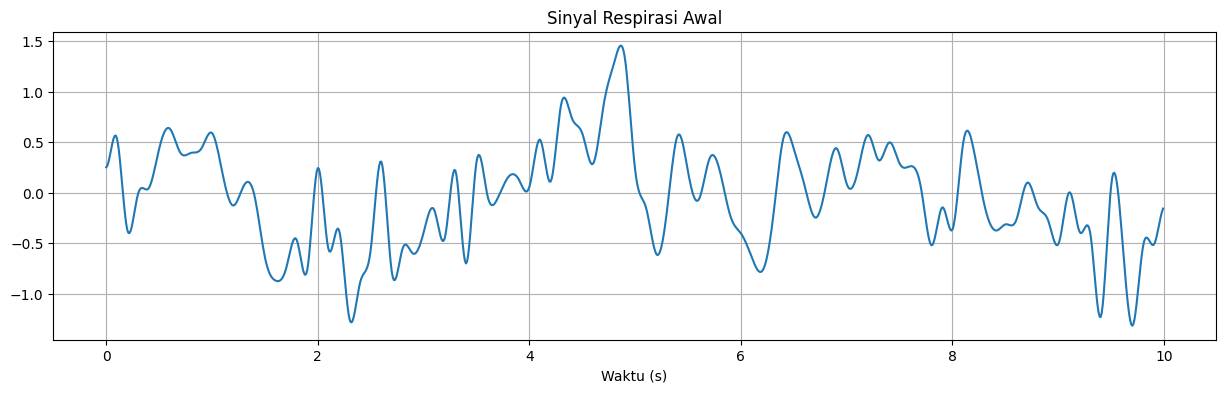

In [56]:

duration = 182
sampling_rate = 100
noise_level = 0.82
resp_rate = 18  # BPM
random_state = 30401

resp = nk.rsp_simulate(duration=duration, sampling_rate=sampling_rate,
                       respiratory_rate=resp_rate, noise=noise_level, random_state=random_state)
time_rsp = np.linspace(0, duration, len(resp))

plt.figure(figsize=(15, 4))
plt.plot(time_rsp[:1000], resp[:1000])
plt.title("Sinyal Respirasi Awal")
plt.xlabel("Waktu (s)")
plt.grid()
plt.show()


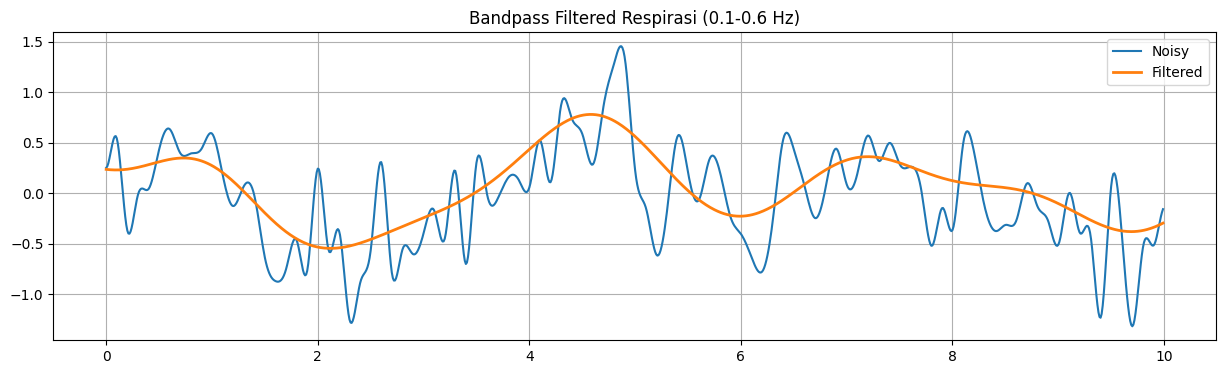

In [57]:

# Frekuensi napas normal: 0.2–0.5 Hz (12–30 BPM)
lowcut = 0.1
highcut = 0.6

b, a = signal.butter(4, [lowcut, highcut], btype='band', fs=sampling_rate)
resp_f = signal.filtfilt(b, a, resp)

plt.figure(figsize=(15, 4))
plt.plot(time_rsp[:1000], resp[:1000], label="Noisy")
plt.plot(time_rsp[:1000], resp_f[:1000], label="Filtered", linewidth=2)
plt.legend()
plt.title("Bandpass Filtered Respirasi (0.1-0.6 Hz)")
plt.grid()
plt.show()


## Penjelasan Frekuensi Cutoff

Rentang frekuensi pernapasan manusia adalah antara **0.1 Hz – 0.6 Hz** (6–36 BPM). Filter bandpass ini membantu menghilangkan noise di luar rentang tersebut, sehingga sinyal napas menjadi lebih halus dan representatif.



## Bagian 3: Filter Audio Suara Berisik

Silakan rekam suara Anda selama 20 detik dengan **noise dari kipas atau AC** menggunakan alat seperti handphone. Pastikan menyebutkan nama, asal daerah, dan hobi.

Simpan sebagai file bernama `audio.wav`, lalu unggah ke notebook ini.


In [58]:
# Baca file
data, sr = sf.read("audio.wav")

# Konversi stereo ke mono jika perlu
if len(data.shape) == 2:  # jika stereo
    data = np.mean(data, axis=1)

# Normalisasi ke int16
scaled_data = np.int16(data / np.max(np.abs(data)) * 32767)

# Simpan ke file baru
write("audio_fixed.wav", sr, scaled_data)

# Putar ulang
ipd.Audio("audio_fixed.wav")


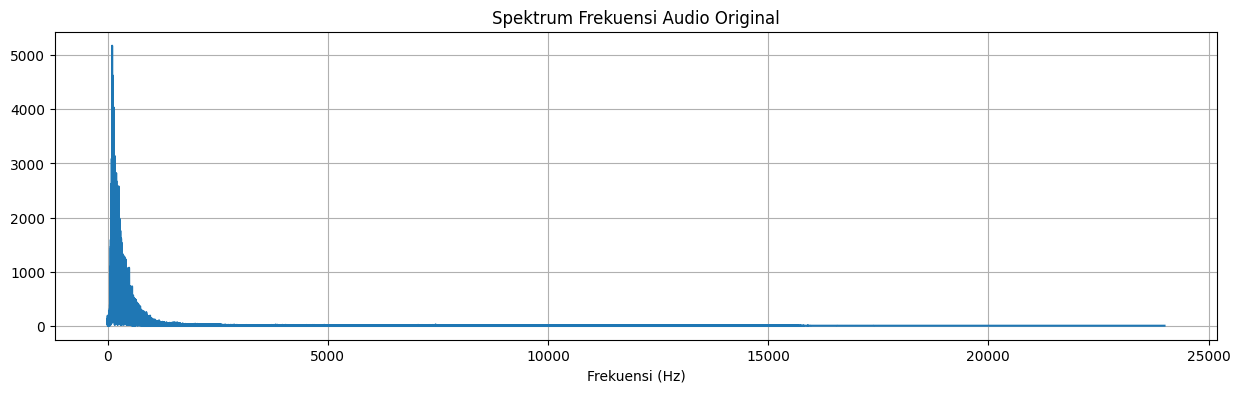

In [ ]:

# FFT Audio Original
n = len(data)
frequencies = fftfreq(n, 1/sr)
fft_vals = np.abs(fft(data))

plt.figure(figsize=(15, 4))
plt.plot(frequencies[:n//2], fft_vals[:n//2])
plt.title("Spektrum Frekuensi Audio Original")
plt.xlabel("Frekuensi (Hz)")
plt.grid()
plt.show()


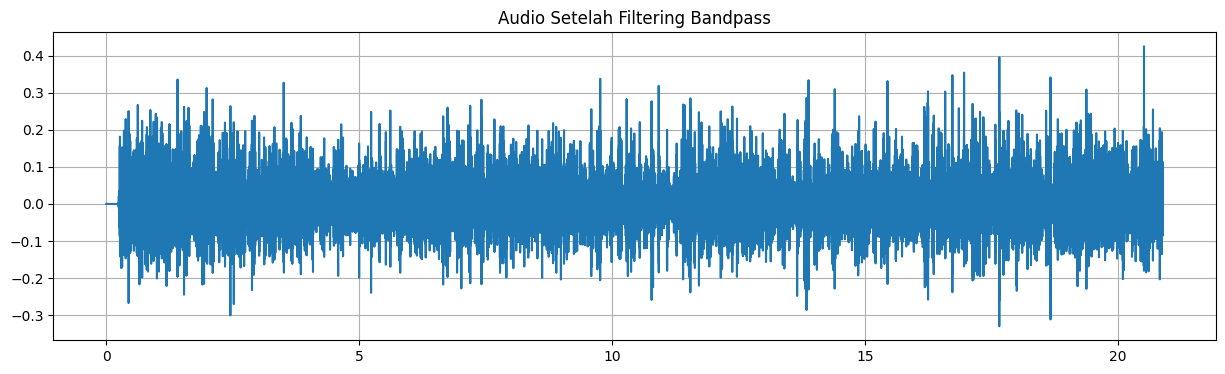

In [60]:

# Gunakan filter bandpass di frekuensi suara manusia 300–3400 Hz
lowcut = 300
highcut = 3400
b, a = signal.butter(6, [lowcut, highcut], btype='band', fs=sr)
data_filtered = signal.filtfilt(b, a, data)

plt.figure(figsize=(15, 4))
plt.plot(t, data_filtered)
plt.title("Audio Setelah Filtering Bandpass")
plt.grid()
plt.show()

ipd.Audio(data_filtered, rate=sr)


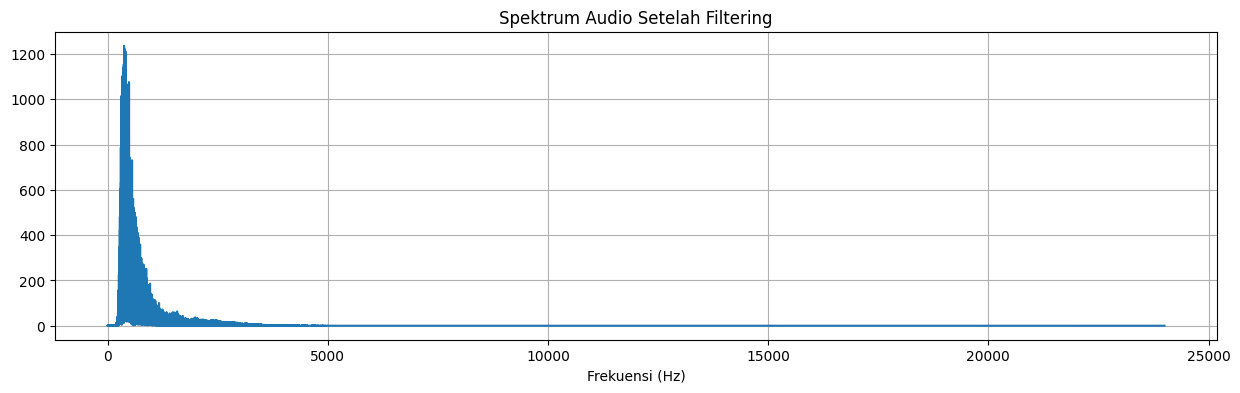

In [61]:

fft_vals_f = np.abs(fft(data_filtered))
plt.figure(figsize=(15, 4))
plt.plot(frequencies[:n//2], fft_vals_f[:n//2])
plt.title("Spektrum Audio Setelah Filtering")
plt.xlabel("Frekuensi (Hz)")
plt.grid()
plt.show()


## Referensi

<ul>
<li>https://arxiv.org/abs/2002.03130?</li>
<li>https://www.ijcrt.org/papers/IJCRT2310086.pdf?</li>
<li>https://chatgpt.com/share/682e9eb7-3880-8007-8a49-9012826810f6</li>
</ul>

## Github


<ul><li>https://github.com/Arof182/Pengolahan-Sinyal-Digital/tree/d755fef52dcf2e923aaddce429a75cebe3d08eb9/Hands-on-2</li></ul>